# Kitchen PNL – Exploratory Data Analysis
**Dataset**: Cloud Kitchen Profit & Loss – Store Level

This notebook covers:
1. Loading and inspecting the data
2. Cleaning and deriving new columns
3. Univariate analysis (individual columns)
4. Bivariate / multivariate analysis
5. Variance deep-dive
6. Key takeaways

In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# makes charts look a bit nicer
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load & First Look

In [6]:
# load the file – make sure it's in the same folder as this notebook
df = pd.read_csv('Kittchen_PNL_Data.csv')

print('Shape:', df.shape)
print()
print('Columns:', df.columns.tolist())

Shape: (2100, 17)

Columns: ['MONTH', 'CITY', 'STORE', 'STATUS', 'ZONE MAPPING', 'ORDER COUNT', 'CART SALES', 'DISCOUNT', 'NET REVENUE', 'IDEAL FOOD COST', 'GROSS MARGIN', 'KITCHEN EBITDA', 'VARIANCE', 'REVENUE COHORT', 'CM COHORT', 'EBITDA CATEGORY', 'EBITDA COHORT']


In [7]:
# quick look at first few rows
df.head()

,MONTH,CITY,STORE,STATUS,ZONE MAPPING,ORDER COUNT,CART SALES,DISCOUNT,NET REVENUE,IDEAL FOOD COST,GROSS MARGIN,KITCHEN EBITDA,VARIANCE,REVENUE COHORT,CM COHORT,EBITDA CATEGORY,EBITDA COHORT
0,Oct-23,Ahmedabad,Ramos-Martin,Inactive,West,14270,6554333.68,1163493.98,5434068.17,1763679.62,3614747.39,2374914.55,29664.62,INR 20 to 30 lacs,0% to 10%,EBITDA +ve,More than 20%
1,Nov-23,Ahmedabad,Ramos-Martin,Inactive,West,8528,2637625.82,636015.27,2146679.55,638415.30,1414249.00,151761.82,11769.85,INR 20 to 30 lacs,More than 30%,EBITDA +ve,More than 20%
2,Dec-23,Ahmedabad,Ramos-Martin,Inactive,West,10798,4364193.67,1283840.18,3188606.71,1085080.58,2036999.44,736811.76,23376.83,INR 30 to 40 lacs,0% to 10%,EBITDA +ve,0% to 10%
3,Jan-24,Ahmedabad,Ramos-Martin,Inactive,West,7804,3479969.32,854797.46,2734306.33,1180892.50,1451140.55,229924.26,26162.41,INR 20 to 30 lacs,0% to 10%,EBITDA +ve,More than 20%
4,Feb-24,Ahmedabad,Ramos-Martin,Inactive,West,10060,4771378.71,1290900.38,3602124.88,1114846.94,2394567.16,1114151.65,19944.97,INR 20 to 30 lacs,More than 30%,EBITDA -ve,0% to 10%


In [8]:
# data types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MONTH            2100 non-null   object 
 1   CITY             2100 non-null   object 
 2   STORE            2100 non-null   object 
 3   STATUS           2100 non-null   object 
 4   ZONE MAPPING     2100 non-null   object 
 5   ORDER COUNT      2100 non-null   int64  
 6   CART SALES       2100 non-null   float64
 7   DISCOUNT         2100 non-null   float64
 8   NET REVENUE      2100 non-null   float64
 9   IDEAL FOOD COST  2100 non-null   float64
 10  GROSS MARGIN     2100 non-null   float64
 11  KITCHEN EBITDA   2100 non-null   float64
 12  VARIANCE         2100 non-null   float64
 13  REVENUE COHORT   2100 non-null   object 
 14  CM COHORT        2100 non-null   object 
 15  EBITDA CATEGORY  2100 non-null   object 
 16  EBITDA COHORT    2100 non-null   object 
dtypes: float64(7),

In [9]:
# check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
MONTH              0
CITY               0
STORE              0
STATUS             0
ZONE MAPPING       0
ORDER COUNT        0
CART SALES         0
DISCOUNT           0
NET REVENUE        0
IDEAL FOOD COST    0
GROSS MARGIN       0
KITCHEN EBITDA     0
VARIANCE           0
REVENUE COHORT     0
CM COHORT          0
EBITDA CATEGORY    0
EBITDA COHORT      0
dtype: int64


In [10]:
# basic stats on numeric columns
df.describe().round(2)

,ORDER COUNT,CART SALES,DISCOUNT,NET REVENUE,IDEAL FOOD COST,GROSS MARGIN,KITCHEN EBITDA,VARIANCE
count,2100.00,2100.00,2100.00,2100.00,2100.00,2100.00,2100.00,2100.00
mean,11045.37,4400590.93,983999.17,3505318.18,1362715.82,2043379.98,684722.99,20176.59
std,2290.86,1119387.56,313628.80,894839.02,415176.67,572423.90,581091.76,5783.20
min,7002.00,2177492.78,352197.59,1726080.29,556791.06,862833.61,-585850.42,10018.48
25%,9097.00,3520108.02,744239.18,2817943.14,1059970.99,1612743.97,252044.98,15494.86
50%,10987.00,4295394.86,938806.11,3427512.13,1298579.45,1980659.52,617617.66,20195.19
75%,12986.75,5184657.06,1176024.10,4127204.07,1618120.15,2423338.07,1076676.29,25180.83
max,14999.00,7471638.14,2147223.89,6167425.46,2797857.29,4172729.98,2834680.28,29993.94


## 2. Data Cleaning & Derived Columns

In [11]:
# check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [12]:
# set month as ordered category so charts plot in chronological order
month_order = ['Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Mar-24']
df['MONTH'] = pd.Categorical(df['MONTH'], categories=month_order, ordered=True)

print('Months in dataset:', df['MONTH'].unique().tolist())

Months in dataset: ['Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Mar-24']


In [13]:
# derive GM%  =  Gross Margin / Net Revenue
df['GM%'] = (df['GROSS MARGIN'] / df['NET REVENUE'] * 100).round(2)

# Contribution Margin and CM% – at this level of the PNL, CM ≈ Gross Margin
df['CM'] = df['GROSS MARGIN']
df['CM%'] = df['GM%']

# EBITDA alias for cleaner code
df['EBITDA'] = df['KITCHEN EBITDA']
df['EBITDA%'] = (df['EBITDA'] / df['NET REVENUE'] * 100).round(2)

# Variance as % of Net Revenue
df['VARIANCE%'] = (df['VARIANCE'] / df['NET REVENUE'] * 100).round(2)

# Discount %
df['DISCOUNT%'] = (df['DISCOUNT'] / df['CART SALES'] * 100).round(2)

print('New columns added: GM%, CM, CM%, EBITDA, EBITDA%, VARIANCE%, DISCOUNT%')
df[['NET REVENUE', 'GM%', 'CM%', 'EBITDA%', 'VARIANCE%', 'DISCOUNT%']].head()

New columns added: GM%, CM, CM%, EBITDA, EBITDA%, VARIANCE%, DISCOUNT%


,NET REVENUE,GM%,CM%,EBITDA%,VARIANCE%,DISCOUNT%
0,5434068.17,66.52,66.52,43.70,0.55,17.75
1,2146679.55,65.88,65.88,7.07,0.55,24.11
2,3188606.71,63.88,63.88,23.11,0.73,29.42
3,2734306.33,53.07,53.07,8.41,0.96,24.56
4,3602124.88,66.48,66.48,30.93,0.55,27.06


## 3. Univariate Analysis

In [14]:
# How many unique stores, cities?
print('Unique cities :', df['CITY'].nunique(), '->', df['CITY'].unique().tolist())
print('Unique stores :', df['STORE'].nunique())
print('Status values :', df['STATUS'].unique().tolist())

Unique cities : 5 -> ['Ahmedabad', 'Pune', 'Bangalore', 'Mumbai', 'Hyderabad']
Unique stores : 344
Status values : ['Inactive', 'Active']


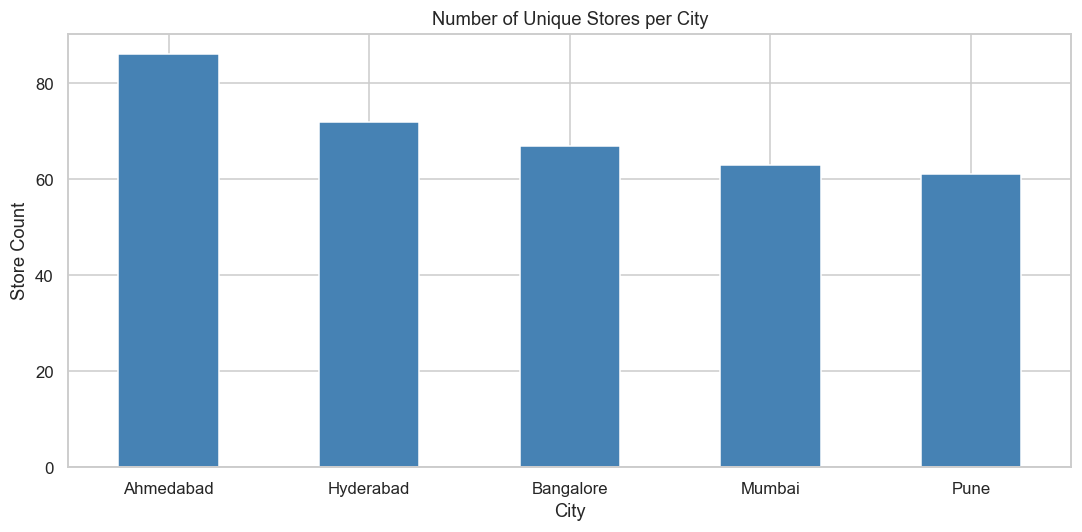

In [15]:
# stores per city
stores_per_city = df.groupby('CITY')['STORE'].nunique().sort_values(ascending=False)

stores_per_city.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Unique Stores per City')
plt.xlabel('City')
plt.ylabel('Store Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\Siddharth\AppData\Local\Temp\ipykernel_21432\4226407521.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CITY', y='NET REVENUE', ax=axes[1], palette='Set2')
C:\Users\Siddharth\AppData\Local\Temp\ipykernel_21432\4226407521.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)


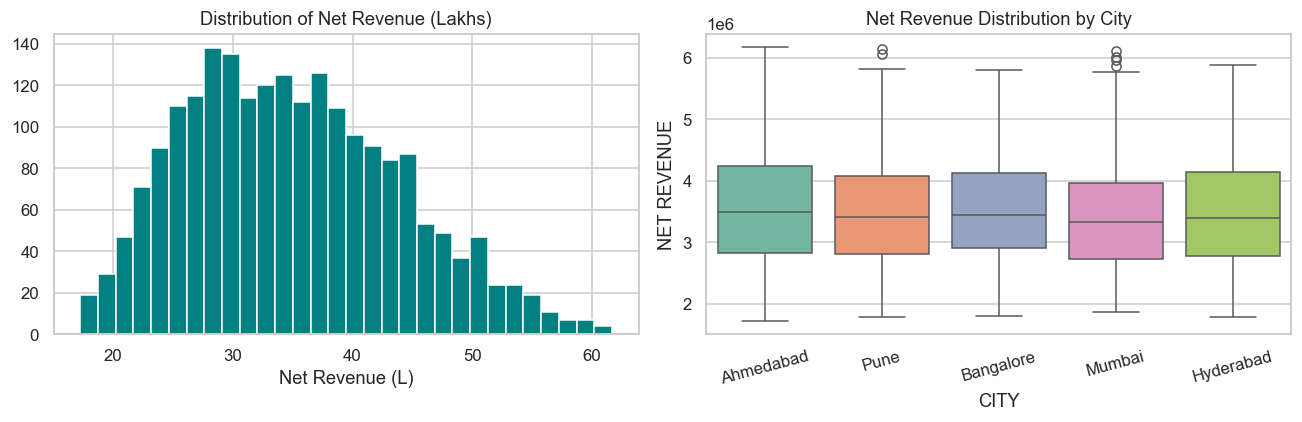

In [16]:
# distribution of Net Revenue
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['NET REVENUE'] / 1e5, bins=30, color='teal', edgecolor='white')
axes[0].set_title('Distribution of Net Revenue (Lakhs)')
axes[0].set_xlabel('Net Revenue (L)')

sns.boxplot(data=df, x='CITY', y='NET REVENUE', ax=axes[1], palette='Set2')
axes[1].set_title('Net Revenue Distribution by City')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

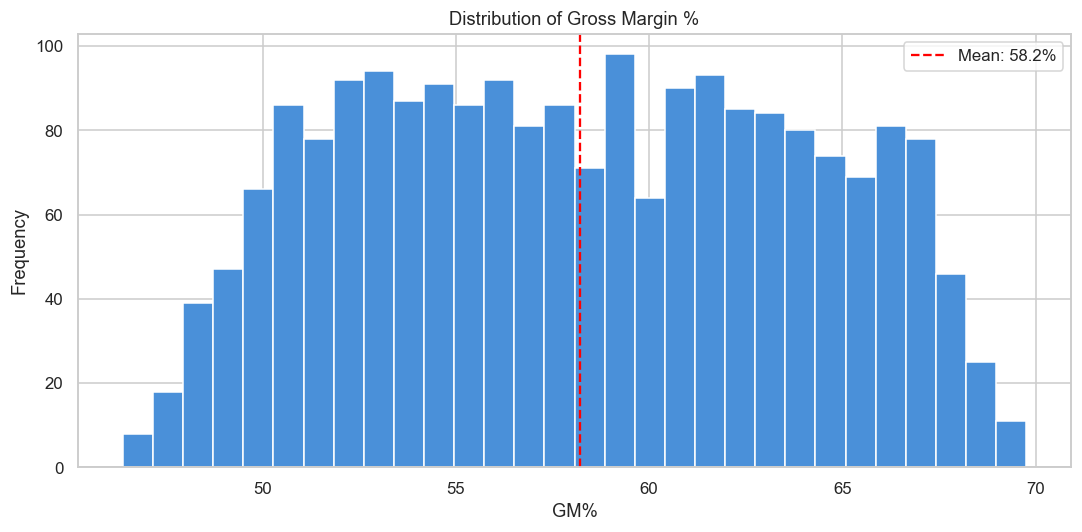

In [17]:
# distribution of GM%
df['GM%'].hist(bins=30, color='#4a90d9', edgecolor='white')
plt.axvline(df['GM%'].mean(), color='red', linestyle='--', label=f"Mean: {df['GM%'].mean():.1f}%")
plt.title('Distribution of Gross Margin %')
plt.xlabel('GM%')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

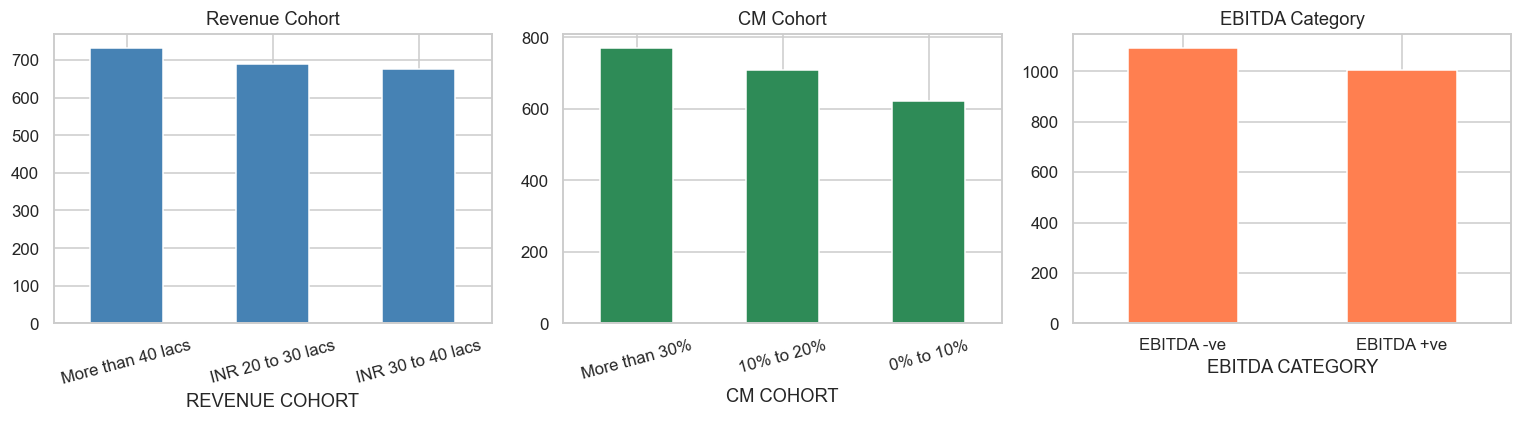

In [18]:
# cohort breakdown counts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['REVENUE COHORT'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Revenue Cohort')
axes[0].tick_params(axis='x', rotation=15)

df['CM COHORT'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('CM Cohort')
axes[1].tick_params(axis='x', rotation=15)

df['EBITDA CATEGORY'].value_counts().plot(kind='bar', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('EBITDA Category')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Bivariate / Multivariate Analysis

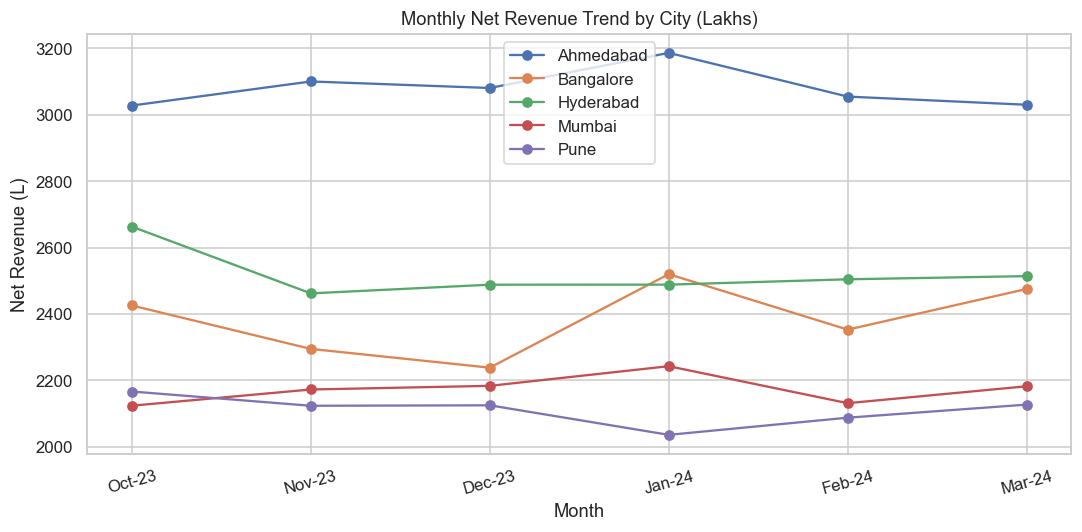

In [19]:
# monthly revenue trend per city
monthly_city = df.groupby(['MONTH', 'CITY'], observed=True)['NET REVENUE'].sum().reset_index()

cities = monthly_city['CITY'].unique()
for city in cities:
    sub = monthly_city[monthly_city['CITY'] == city]
    plt.plot(sub['MONTH'].astype(str), sub['NET REVENUE'] / 1e5, marker='o', label=city)

plt.title('Monthly Net Revenue Trend by City (Lakhs)')
plt.xlabel('Month')
plt.ylabel('Net Revenue (L)')
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

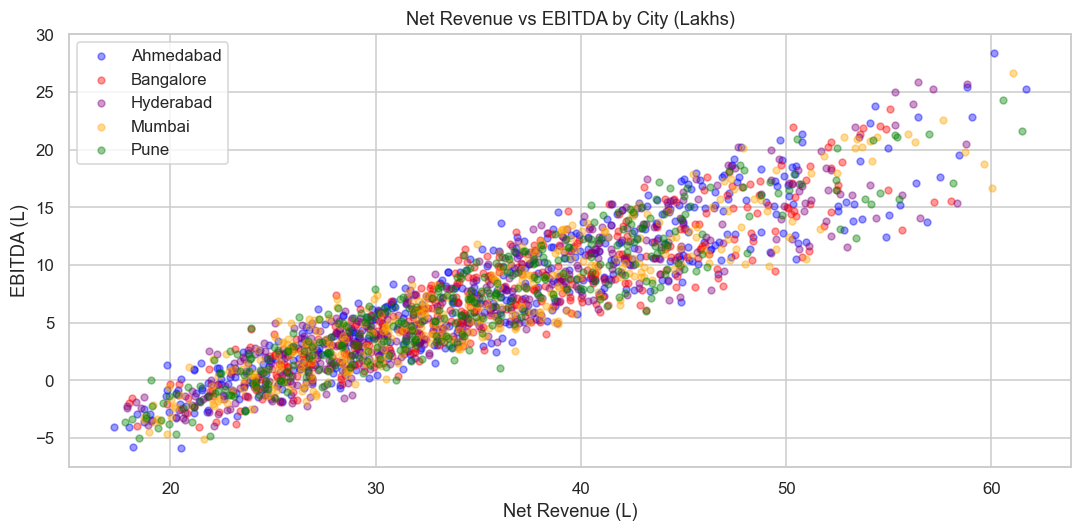

In [20]:
# scatter: Net Revenue vs EBITDA coloured by city
colors = {'Ahmedabad': 'blue', 'Pune': 'green', 'Bangalore': 'red', 'Mumbai': 'orange', 'Hyderabad': 'purple'}

for city, group in df.groupby('CITY'):
    plt.scatter(group['NET REVENUE'] / 1e5, group['EBITDA'] / 1e5,
                alpha=0.4, label=city, color=colors.get(city, 'grey'), s=20)

plt.title('Net Revenue vs EBITDA by City (Lakhs)')
plt.xlabel('Net Revenue (L)')
plt.ylabel('EBITDA (L)')
plt.legend()
plt.tight_layout()
plt.show()

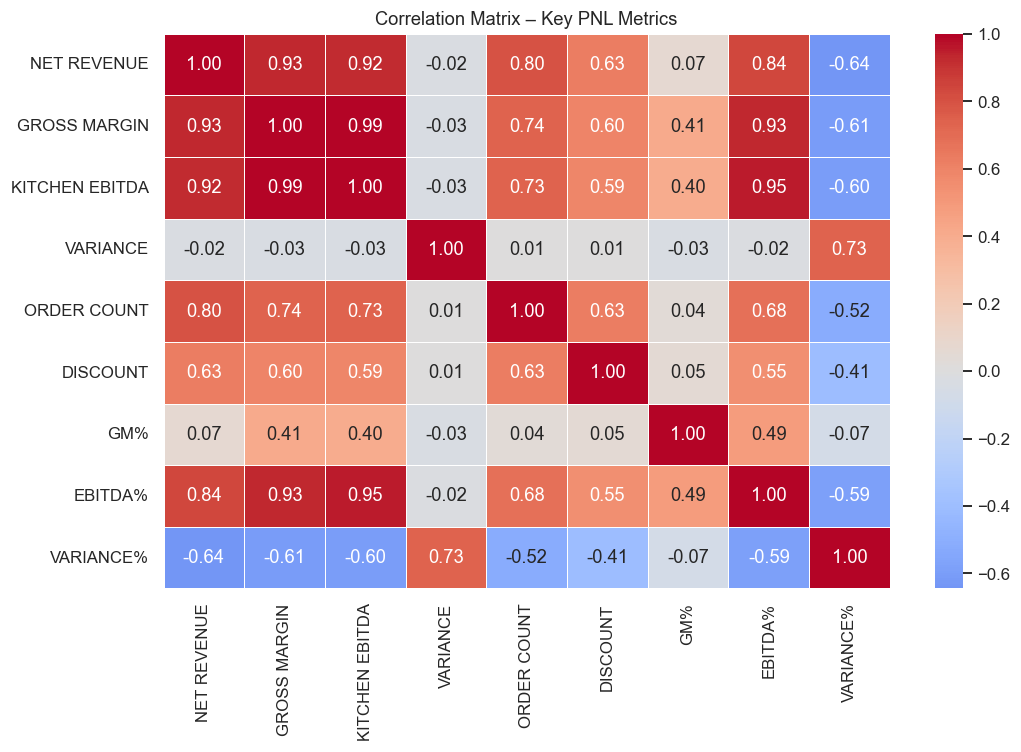

In [21]:
# correlation heatmap of numeric columns
num_cols = ['NET REVENUE', 'GROSS MARGIN', 'KITCHEN EBITDA', 'VARIANCE',
            'ORDER COUNT', 'DISCOUNT', 'GM%', 'EBITDA%', 'VARIANCE%']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix – Key PNL Metrics')
plt.tight_layout()
plt.show()

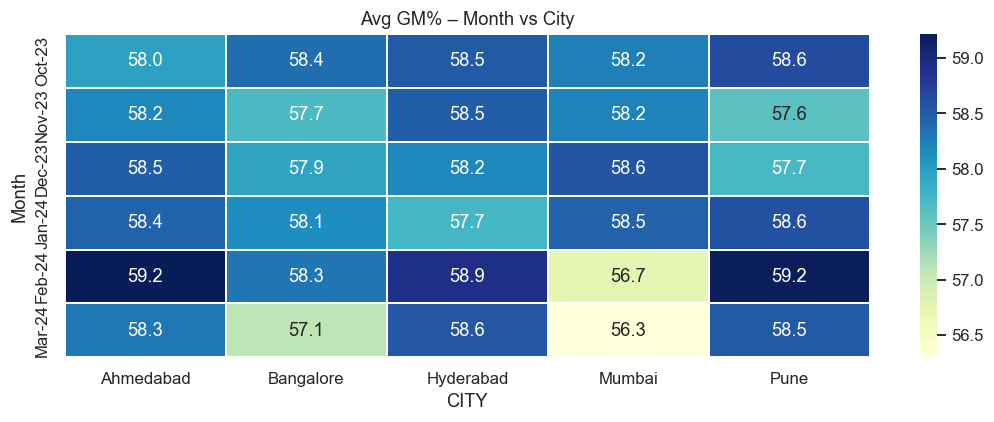

In [22]:
# average GM% per city per month – pivot heatmap
pivot_gm = df.groupby(['MONTH', 'CITY'], observed=True)['GM%'].mean().unstack('CITY')

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_gm, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.3)
plt.title('Avg GM% – Month vs City')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

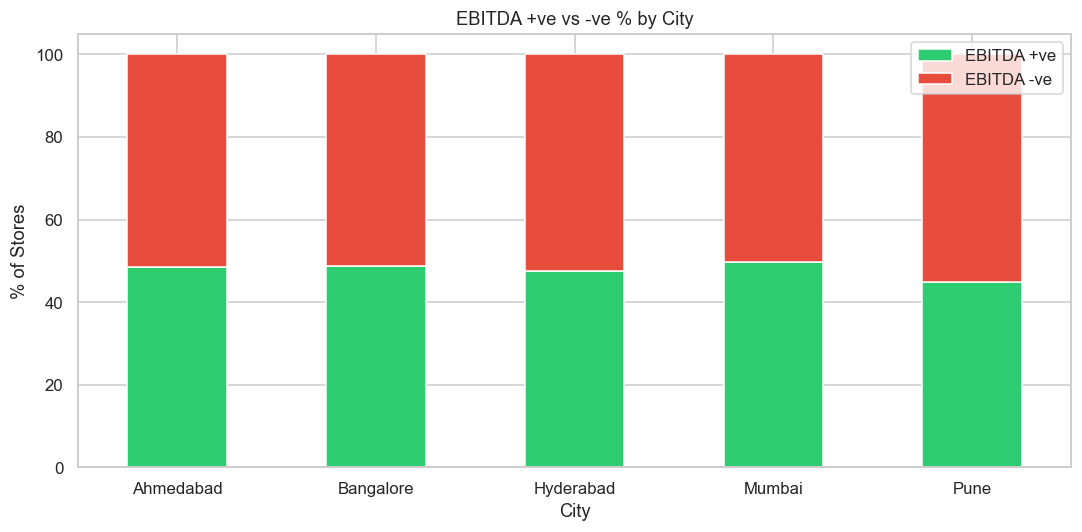

In [23]:
# EBITDA positive vs negative – what % in each city?
ebitda_city = (df.groupby(['CITY', 'EBITDA CATEGORY'])
               .size()
               .unstack('EBITDA CATEGORY')
               .fillna(0))

ebitda_city_pct = ebitda_city.div(ebitda_city.sum(axis=1), axis=0) * 100

ebitda_city_pct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='white')
plt.title('EBITDA +ve vs -ve % by City')
plt.xlabel('City')
plt.ylabel('% of Stores')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 5. Variance Deep-Dive

In [24]:
print('Variance stats (INR):')
print(df['VARIANCE'].describe().round(2))
print()
print('Variance% stats:')
print(df['VARIANCE%'].describe().round(2))

Variance stats (INR):
count     2100.00
mean     20176.59
std       5783.20
min      10018.48
25%      15494.86
50%      20195.19
75%      25180.83
max      29993.94
Name: VARIANCE, dtype: float64

Variance% stats:
count    2100.00
mean        0.62
std         0.24
min         0.18
25%         0.43
50%         0.58
75%         0.77
max         1.49
Name: VARIANCE%, dtype: float64


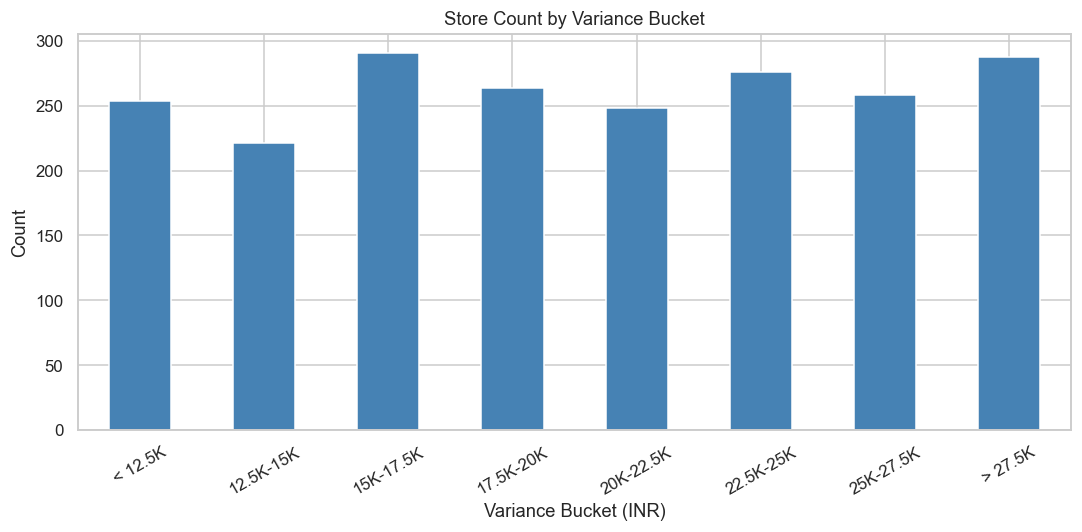

In [25]:
# create variance buckets
var_bins   = [0, 12500, 15000, 17500, 20000, 22500, 25000, 27500, 30001]
var_labels = ['< 12.5K', '12.5K-15K', '15K-17.5K', '17.5K-20K',
              '20K-22.5K', '22.5K-25K', '25K-27.5K', '> 27.5K']

df['VARIANCE_BUCKET'] = pd.cut(df['VARIANCE'], bins=var_bins, labels=var_labels, right=False)

# how many stores fall in each bucket?
var_bucket_counts = df['VARIANCE_BUCKET'].value_counts().sort_index()

var_bucket_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Store Count by Variance Bucket')
plt.xlabel('Variance Bucket (INR)')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Avg Variance% per Revenue Cohort:
REVENUE COHORT
INR 30 to 40 lacs    0.622
More than 40 lacs    0.616
INR 20 to 30 lacs    0.610
Name: VARIANCE%, dtype: float64


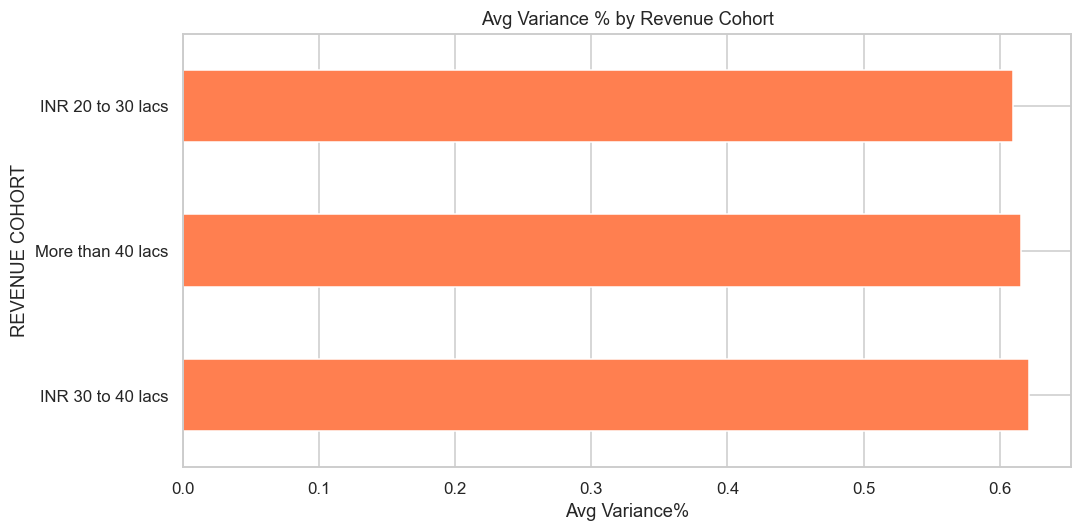

In [26]:
# avg variance % per revenue cohort
avg_var_cohort = df.groupby('REVENUE COHORT')['VARIANCE%'].mean().sort_values(ascending=False)
print('Avg Variance% per Revenue Cohort:')
print(avg_var_cohort.round(3))

avg_var_cohort.plot(kind='barh', color='coral', edgecolor='white')
plt.title('Avg Variance % by Revenue Cohort')
plt.xlabel('Avg Variance%')
plt.tight_layout()
plt.show()

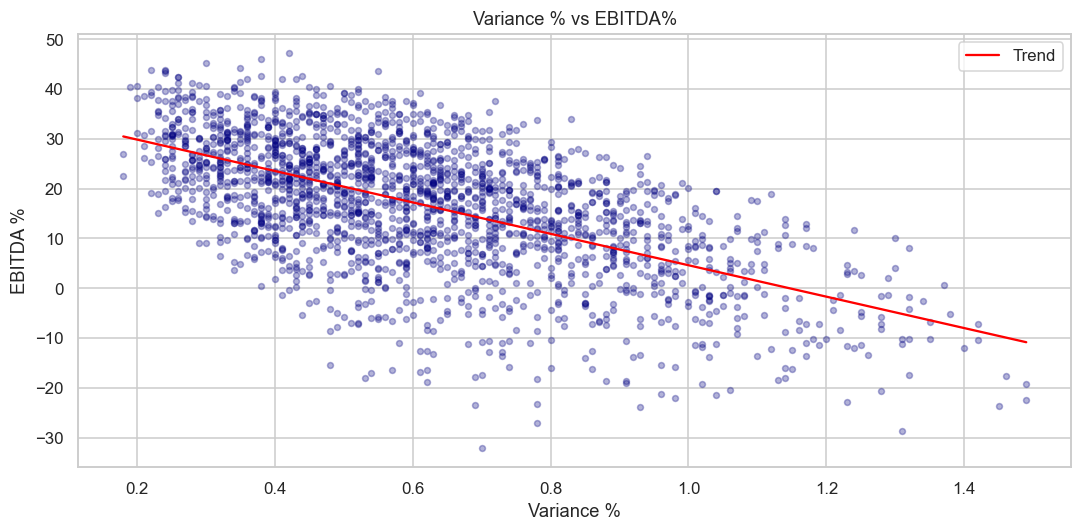

Correlation between Variance% and EBITDA%: -0.588


In [27]:
# does higher variance mean lower EBITDA? scatter
plt.scatter(df['VARIANCE%'], df['EBITDA%'], alpha=0.3, color='navy', s=15)
# add a trend line
z = np.polyfit(df['VARIANCE%'], df['EBITDA%'], 1)
p = np.poly1d(z)
x_range = np.linspace(df['VARIANCE%'].min(), df['VARIANCE%'].max(), 100)
plt.plot(x_range, p(x_range), color='red', linewidth=1.5, label='Trend')

plt.title('Variance % vs EBITDA%')
plt.xlabel('Variance %')
plt.ylabel('EBITDA %')
plt.legend()
plt.tight_layout()
plt.show()

corr_val = df['VARIANCE%'].corr(df['EBITDA%'])
print(f'Correlation between Variance% and EBITDA%: {corr_val:.3f}')

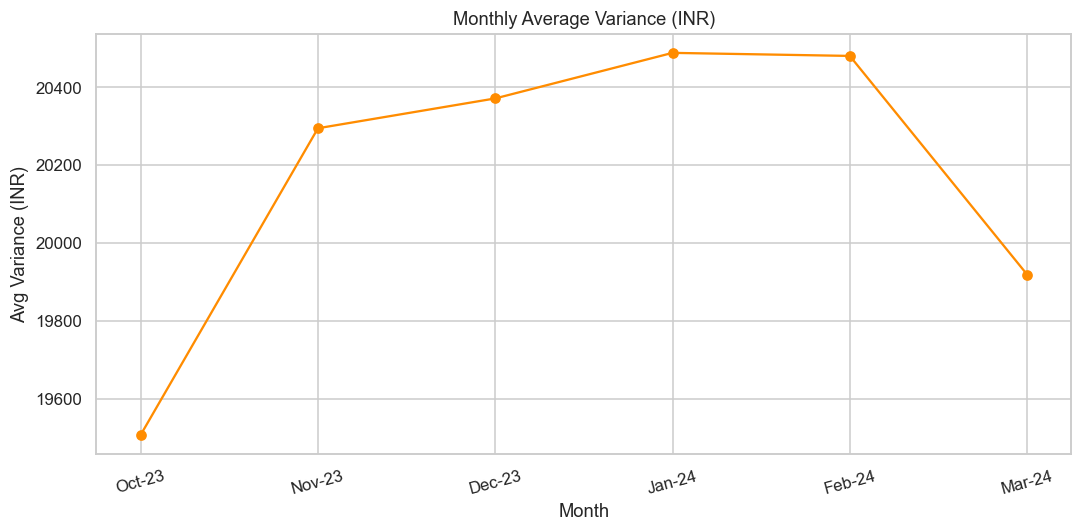

In [28]:
# monthly average variance trend
monthly_var = df.groupby('MONTH', observed=True)['VARIANCE'].mean()

monthly_var.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Average Variance (INR)')
plt.xlabel('Month')
plt.ylabel('Avg Variance (INR)')
plt.xticks(range(len(monthly_var)), monthly_var.index.tolist(), rotation=15)
plt.tight_layout()
plt.show()

Store count pivot (Month x Revenue Band):
REV_BAND  < 20L  20L-30L  30L-40L  40L-50L  > 50L
MONTH                                            
Oct-23        8      101      135       83     23
Nov-23        7      111      133       73     24
Dec-23        5      111      143       72     17
Jan-24        8      110      117       79     35
Feb-24        9      106      142       77     15
Mar-24        8      109      119       84     27


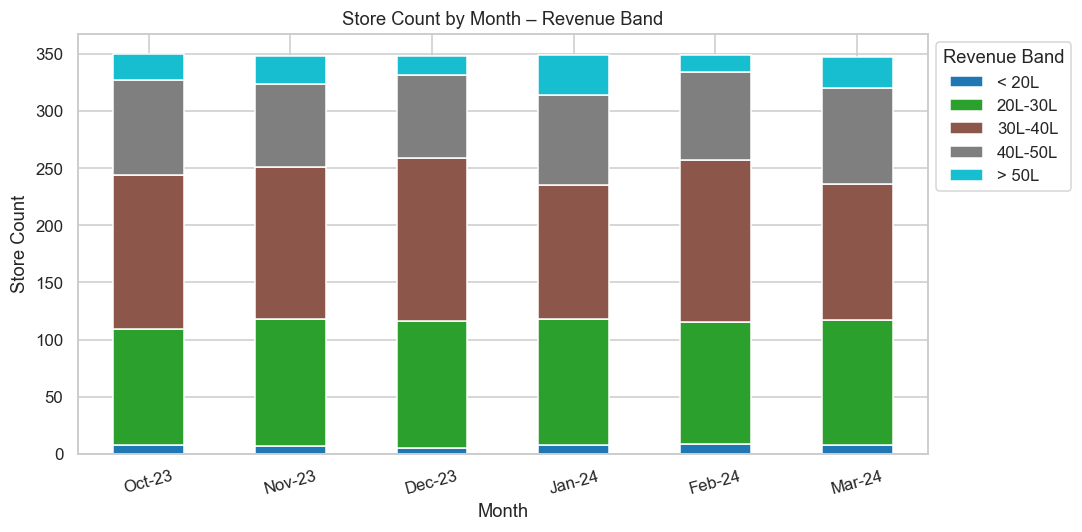

In [29]:
# store count pivot: month x revenue band
rev_bins   = [0, 2_000_000, 3_000_000, 4_000_000, 5_000_000, 99_999_999]
rev_labels = ['< 20L', '20L-30L', '30L-40L', '40L-50L', '> 50L']

df['REV_BAND'] = pd.cut(df['NET REVENUE'], bins=rev_bins, labels=rev_labels, right=False)

store_pivot = (df.groupby(['MONTH', 'REV_BAND'], observed=True)['STORE']
               .nunique()
               .unstack('REV_BAND')
               .fillna(0)
               .astype(int))

print('Store count pivot (Month x Revenue Band):')
print(store_pivot)

store_pivot.plot(kind='bar', stacked=True, colormap='tab10', edgecolor='white', figsize=(10, 5))
plt.title('Store Count by Month – Revenue Band')
plt.xlabel('Month')
plt.ylabel('Store Count')
plt.xticks(rotation=15)
plt.legend(title='Revenue Band', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 6. Key Takeaways

Based on the EDA above, here are the main findings:

1. **Data shape**: 2,100 rows covering 344 unique stores across 5 cities and 6 months (Oct-23 to Mar-24).

2. **Revenue spread**: Net Revenue ranges from ~₹17L to ₹62L per store per month. Mumbai and Bangalore tend to have higher revenues.

3. **Gross Margin is healthy**: Average GM% is ~58%, which is good for cloud kitchens. Most stores fall in the 50–65% band.

4. **EBITDA split**: Roughly two-thirds of stores are EBITDA positive. Negative EBITDA stores appear more in lower revenue cohorts.

5. **Variance (wastage)**: Average wastage is ~₹20,000 per store per month. Variance% is very small relative to revenue (< 1%), so it's not a huge P&L driver, but it can be optimised.

6. **Variance vs EBITDA**: There is a mild negative correlation – higher wastage slightly reduces EBITDA, as expected.

7. **Month trend**: Revenue generally picks up from Oct-23 to Mar-24, with some dip in Nov-23 (festive hangover effect possibly).

8. **No missing data**: The dataset is clean with zero nulls.